# Theory-validation experiment: kernel gradient descent on $S^1$

## Goal

The purpose of this experiment is to validate the analytic NTK theory on the circle $S^1$ in a clean, deterministic setting.

We work with the infinite-width kernel directly, not a finite-width neural network. The main question is:

- does the discrete kernel gradient descent dynamics on a fine grid behave the way the continuum Fourier theory predicts?

More specifically, we want to check that:

1. the empirical eigenvalues of the discrete kernel matrix match the analytic continuum Fourier eigenvalues up to the expected discretization scaling,
2. the residual decays mode-by-mode at rates predicted by those eigenvalues,
3. sampled Fourier modes on the circle behave like approximate eigendirections of the kernel matrix.

---

## Setup

We consider inputs on the unit circle,
$$
x(\gamma) = (\cos \gamma, \sin \gamma), \qquad \gamma \in [0,2\pi),
$$
and use an evenly spaced grid of training angles
$$
\gamma_j = \frac{2\pi j}{n}, \qquad j=0,\dots,n-1.
$$

The target function is a finite Fourier mixture with a few selected modes, for example
$$
f^*(\gamma)
=
a_1 \cos(k_1 \gamma)
+
a_2 \cos(k_2 \gamma)
+
a_3 \cos(k_3 \gamma).
$$

We then build the analytic infinite-width NTK Gram matrix
$$
\Theta_{XX} = [\Theta(\gamma_i,\gamma_j)]_{i,j=1}^n
$$
using the closed-form kernel on $S^1$.

For the theory-validation run, we use kernel gradient descent directly in prediction space:
$$
y_{\mathrm{pred},t+1}
=
y_{\mathrm{pred},t}
-
\eta\,\Theta_{XX}(y_{\mathrm{pred},t}-y),
$$
with residual
$$
r_t = y_{\mathrm{pred},t}-y.
$$

Equivalently,
$$
r_{t+1} = (I-\eta \Theta_{XX})r_t.
$$

This is the exact discrete-time linear dynamics induced by the frozen infinite-width kernel.

---

This run is designed for theory validation rather than realism.

- We use an evenly spaced grid on the circle so that the discrete kernel matrix approximates the continuum convolution operator well.
- We use a small step size $\eta$ so the discrete dynamics resemble gradient flow.
- We use only a few Fourier modes in the target so the spectral behavior is easy to interpret.
- We analyze the exact discrete kernel matrix used in the experiment, so we can compare observed decay against the exact finite-$n$ prediction.

---

## What we expect theoretically

In the continuum, the operator
$$
(Tf)(\phi)
=
\int \Theta(\phi-\psi) f(\psi)\,\frac{d\psi}{2\pi}
$$
is convolutional on $S^1$, so Fourier modes are eigenfunctions.

If $\lambda_k$ is the eigenvalue associated with mode $k$, then that component of the residual should decay at a rate determined by $\lambda_k$.

In the discrete finite-$n$ experiment, if
$$
\Theta_{XX} = Q \Lambda Q^\top,
$$
then the residual coefficients in the empirical eigenbasis,
$$
\alpha_t = Q^\top r_t,
$$
satisfy
$$
\alpha_k(t+1) = (1-\eta \lambda_k)\alpha_k(t).
$$

So there are two levels of validation:

1. **Exact discrete validation:** compare observed decay against the eigenvalues of the actual matrix $\Theta_{XX}$.
2. **Continuum validation:** compare the discrete spectrum and Fourier-mode behavior against the analytic continuum Fourier theory.

---

## Saved artifacts

The experiment saves several artifacts that together describe the full run.

### `training_task.npz`

This contains the training geometry and target:
- `gamma_train`: evenly spaced angles on the circle
- `X_train`: corresponding 2D circle coordinates
- `y_train`: target values on the grid

This defines the discrete problem we are solving.

---

### `kernel_objects.npz`

This contains the fixed kernel objects:
- `theta_xx`: the discrete NTK Gram matrix
- `evals_emp`: empirical eigenvalues of `theta_xx`
- `evecs`: empirical eigenvectors of `theta_xx`

This is the spectral description of the exact finite-$n$ linear operator used in the dynamics.

---

### `kernel_dynamics.npz`

This contains the kernel gradient descent trajectory:
- `y_pred`: prediction vectors across time
- `r`: residual vectors across time
- `loss`: least-squares loss across time
- `eta`: the step size used

This is the actual observed dynamics we want to analyze.

---

### `mode_projections.npz`

This contains precomputed mode decompositions of the residual:
- `eig_coeffs`: projections of the residual onto empirical kernel eigenvectors
- `cos_k`, `sin_k`: projections of the residual onto sampled Fourier modes

These are the main quantities for studying spectral bias and comparing theory to practice.

---

### `continuum_spectrum.npz`

For the bias kernel, this contains:
- `ks_compare`: mode indices used for comparison
- `lambda_cont`: analytic continuum Fourier eigenvalues
- `lambda_disc_pred`: predicted discrete eigenvalues, using the scaling
  $$
  \lambda_k^{\mathrm{disc}} \approx n \lambda_k^{\mathrm{cont}}
  $$

This gives the continuum theoretical benchmark.

---

## What we will track in this notebook

In the analysis below, we will focus on three main comparisons.

### 1. Discrete spectrum vs continuum spectrum
We compare the empirical eigenvalues of the kernel matrix with the analytic continuum Fourier eigenvalues after the appropriate scaling.

This checks whether the discrete circle kernel is approximating the continuum operator correctly.

### 2. Observed eigenmode decay vs predicted eigenmode decay
Using the empirical eigenvalues and eigenvectors of `theta_xx`, we compare:
- the observed decay of each residual coefficient,
- the ideal decay
  $$
  \alpha_k(t) = (1-\eta\lambda_k)^t \alpha_k(0).
  $$

This is the most exact validation of the kernel-GD implementation.

### 3. Fourier-mode decay
We also inspect projections onto sampled Fourier modes such as $\cos(k\gamma)$.

This connects the finite discrete run back to the continuum Fourier picture on $S^1$ and makes the spectral-bias interpretation more intuitive.

---

## Summary

This experiment gives us a controlled setting in which:

- the kernel is known analytically,
- the discrete dynamics are exactly linear,
- the continuum theory is explicit,
- and the finite-$n$ approximation can be checked directly.

So the notebook analysis is not trying to prove the theory; it is validating that the implementation and the discrete dynamics behave exactly as the spectral theory predicts.

In [1]:
import os, sys
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
print("Project root added to sys.path:", ROOT)

from pathlib import Path
import numpy as np, matplotlib.pyplot as plt
import jax.numpy as jnp
from utils.artifacts_io import latest_run_dir, load_manifest, npz

Project root added to sys.path: /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments


In [48]:
BASE = "../results"; EXP = "kernel_gd_circle_theory"
RUN = latest_run_dir(BASE, EXP)

manifest = load_manifest(RUN)

print("Run directory:", RUN)
print("Manifest keys:", list(manifest.keys()))
print("Meta:", manifest.get("meta", {}))

Run directory: ../results/kernel_gd_circle_theory/kernel_gd_results_grid_1024
Manifest keys: ['training_task', 'kernel_objects', 'kernel_dynamics', 'mode_projections', 'meta', 'runtime_sec', 'continuum_spectrum']
Meta: {'kernel': 'bias', 'init': 'zero', 'n_train': 1024, 'steps': 1000, 'eta': 8.814315343321457e-05, 'eta_scale': 0.05, 'lambda_max_emp': 567.259033203125, 'target_Ks': [0, 1, 2, 3], 'target_amps': [1, 0.9, 0.5, 0.35], 'target_phases': [0.0, 0.0, 0.0, 0.0], 'fourier_modes': [0, 1, 2, 3, 4, 8]}


In [49]:
# Core artifacts
training_task = npz(RUN, manifest["training_task"])
kernel_objects = npz(RUN, manifest["kernel_objects"])
kernel_dynamics = npz(RUN, manifest["kernel_dynamics"])
mode_projections = npz(RUN, manifest["mode_projections"])

In [50]:
continuum_spectrum = None
if "continuum_spectrum" in manifest:
    continuum_spectrum = npz(RUN, manifest["continuum_spectrum"])

In [51]:
gamma_train = training_task["gamma_train"]
X_train = training_task["X_train"]
y_train = training_task["y_train"]

theta_xx = kernel_objects["theta_xx"]
evals_emp = kernel_objects["evals_emp"]
evecs = kernel_objects["evecs"]

y_pred = kernel_dynamics["y_pred"]
r = kernel_dynamics["r"]
loss = kernel_dynamics["loss"]
eta = float(np.ravel(kernel_dynamics["eta"])[0])

eig_coeffs = mode_projections["eig_coeffs"]


In [52]:
print()
print("Loaded shapes:")
print("  gamma_train:", gamma_train.shape)
print("  X_train:", X_train.shape)
print("  y_train:", y_train.shape)
print("  theta_xx:", theta_xx.shape)
print("  evals_emp:", evals_emp.shape)
print("  evecs:", evecs.shape)
print("  y_pred:", y_pred.shape)
print("  r:", r.shape)
print("  loss:", loss.shape)
print("  eig_coeffs:", eig_coeffs.shape)
print("  eta:", eta)

print()
print("Available Fourier projections:")
fourier_keys = [k for k in mode_projections.keys() if k != "eig_coeffs"]
print(sorted(fourier_keys))

if continuum_spectrum is not None:
    print()
    print("Continuum spectrum keys:", list(continuum_spectrum.keys()))


Loaded shapes:
  gamma_train: (1024,)
  X_train: (1024, 2)
  y_train: (1024,)
  theta_xx: (1024, 1024)
  evals_emp: (1024,)
  evecs: (1024, 1024)
  y_pred: (1001, 1024)
  r: (1001, 1024)
  loss: (1001,)
  eig_coeffs: (1001, 1024)
  eta: 8.814315343321457e-05

Available Fourier projections:
['cos_0', 'cos_1', 'cos_2', 'cos_3', 'cos_4', 'cos_8', 'sin_1', 'sin_2', 'sin_3', 'sin_4', 'sin_8']

Continuum spectrum keys: ['ks_compare', 'lambda_cont', 'lambda_disc_pred']


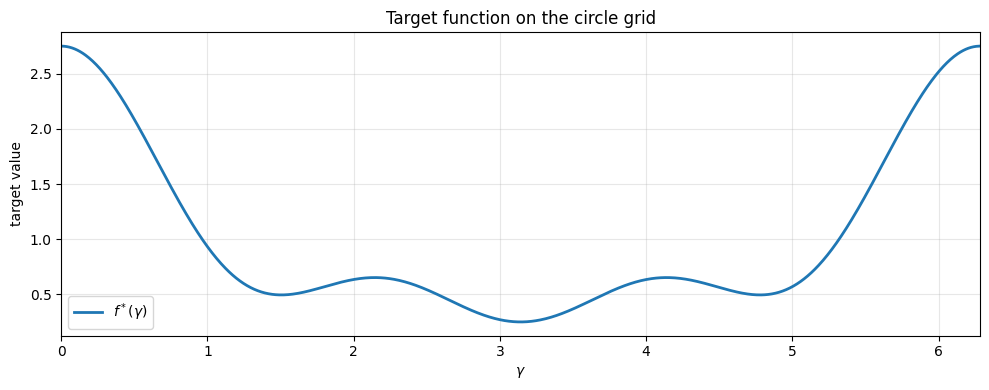

In [53]:
# Plot the target function on the training grid

plt.figure(figsize=(10, 4))
plt.plot(gamma_train, y_train, linewidth=2, label=r"$f^*(\gamma)$")
plt.xlabel(r"$\gamma$")
plt.ylabel("target value")
plt.title("Target function on the circle grid")
plt.xlim(0, 2 * np.pi)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

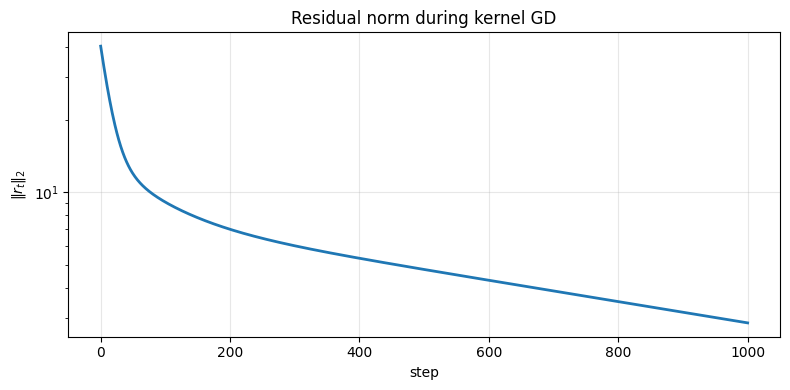

In [54]:
# Residual norm over time

res_norm = np.linalg.norm(r, axis=1)

plt.figure(figsize=(8, 4))
plt.plot(res_norm, linewidth=2)
plt.yscale("log")
plt.xlabel("step")
plt.ylabel(r"$\|r_t\|_2$")
plt.title("Residual norm during kernel GD")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

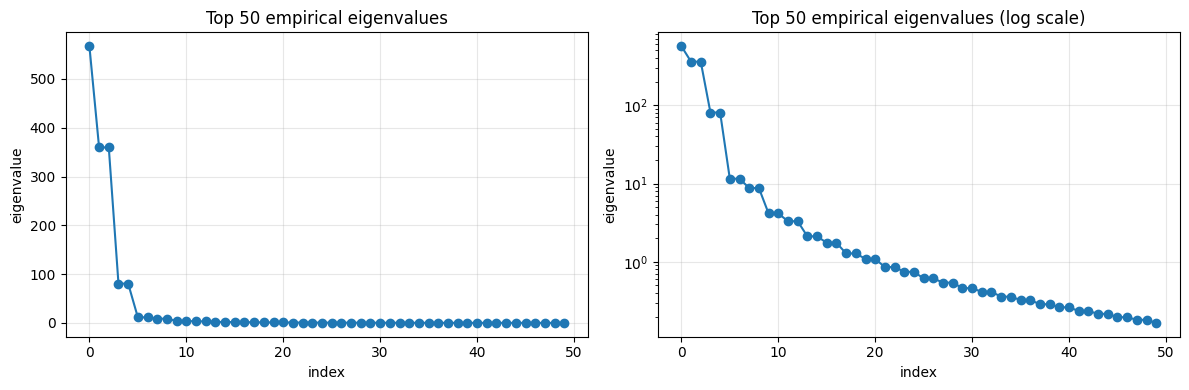

In [55]:
# Empirical spectrum: linear and log scale

k_show = min(50, len(evals_emp))
idx = np.arange(k_show)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(idx, evals_emp[:k_show], marker="o", linewidth=1.5)
axes[0].set_xlabel("index")
axes[0].set_ylabel("eigenvalue")
axes[0].set_title(f"Top {k_show} empirical eigenvalues")
axes[0].grid(True, alpha=0.3)

axes[1].plot(idx, np.maximum(evals_emp[:k_show], 1e-16), marker="o", linewidth=1.5)
axes[1].set_yscale("log")
axes[1].set_xlabel("index")
axes[1].set_ylabel("eigenvalue")
axes[1].set_title(f"Top {k_show} empirical eigenvalues (log scale)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

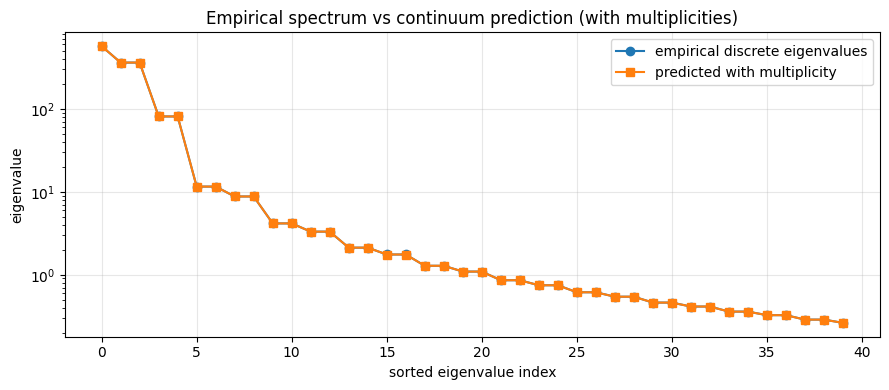

In [62]:
# Multiplicity-aware continuum prediction:
# lambda_0 once, lambda_k twice for k >= 1

if continuum_spectrum is None:
    print("No continuum_spectrum artifact found.")
else:
    ks_compare = np.asarray(continuum_spectrum["ks_compare"])
    lambda_disc_pred = np.asarray(continuum_spectrum["lambda_disc_pred"])

    pred_with_mult = [lambda_disc_pred[0]]
    pred_labels = [0]

    for k in ks_compare[1:]:
        lam = lambda_disc_pred[int(k)]
        pred_with_mult.extend([lam, lam])
        pred_labels.extend([k, k])

    pred_with_mult = np.asarray(pred_with_mult)

    k_show = min(len(evals_emp), len(pred_with_mult), 40)

    plt.figure(figsize=(9, 4))
    plt.plot(
        np.arange(k_show),
        evals_emp[:k_show],
        marker="o",
        linewidth=1.5,
        label="empirical discrete eigenvalues",
    )
    plt.plot(
        np.arange(k_show),
        pred_with_mult[:k_show],
        marker="s",
        linewidth=1.5,
        label=r"predicted with multiplicity",
    )
    plt.xlabel("sorted eigenvalue index")
    plt.yscale("log")
    plt.ylabel("eigenvalue")
    plt.title("Empirical spectrum vs continuum prediction (with multiplicities)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [57]:
diag_modes = list([0, 1, 2, 3])

print("Initial residual projections at t=0")
print("k   cos_k                 sin_k")
for k in diag_modes:
    ckey = f"cos_{k}"
    skey = f"sin_{k}"
    c0 = float(mode_projections[ckey][0]) if ckey in mode_projections else np.nan
    s0 = float(mode_projections[skey][0]) if skey in mode_projections else np.nan
    print(f"{k:<2d}  {c0: .6e}     {s0: .6e}")

Initial residual projections at t=0
k   cos_k                 sin_k
0   -3.200000e+01      nan
1   -2.036468e+01      5.613114e-08
2   -1.131371e+01     -1.544766e-07
3   -7.919599e+00     -6.901495e-07


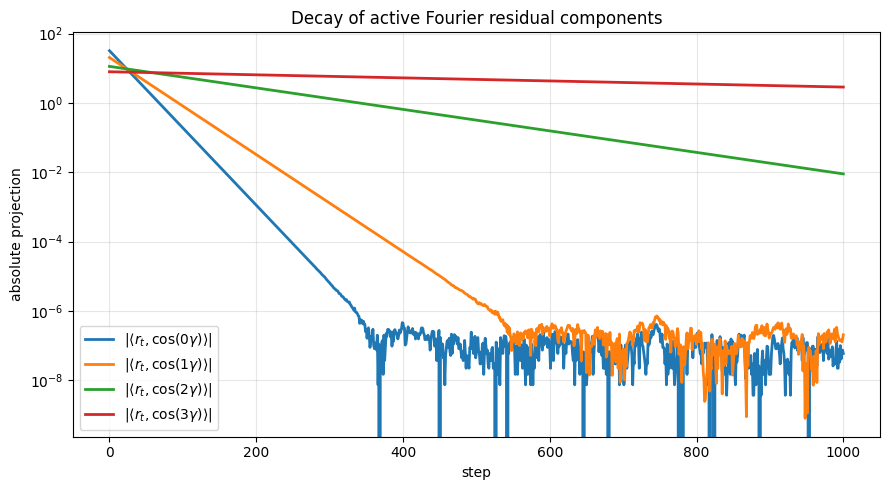

In [58]:
# Fourier-mode decay for the modes injected in the target

modes_to_plot = [0, 1, 2, 3]  # adjust if needed

plt.figure(figsize=(9, 5))

for k in modes_to_plot:
    key = f"cos_{k}"
    if key not in mode_projections:
        print(f"Missing projection: {key}")
        continue

    vals = np.asarray(mode_projections[key])
    plt.plot(np.abs(vals), linewidth=2, label=rf"$|\langle r_t,\cos({k}\gamma)\rangle|$")

plt.yscale("log")
plt.xlabel("step")
plt.ylabel("absolute projection")
plt.title("Decay of active Fourier residual components")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

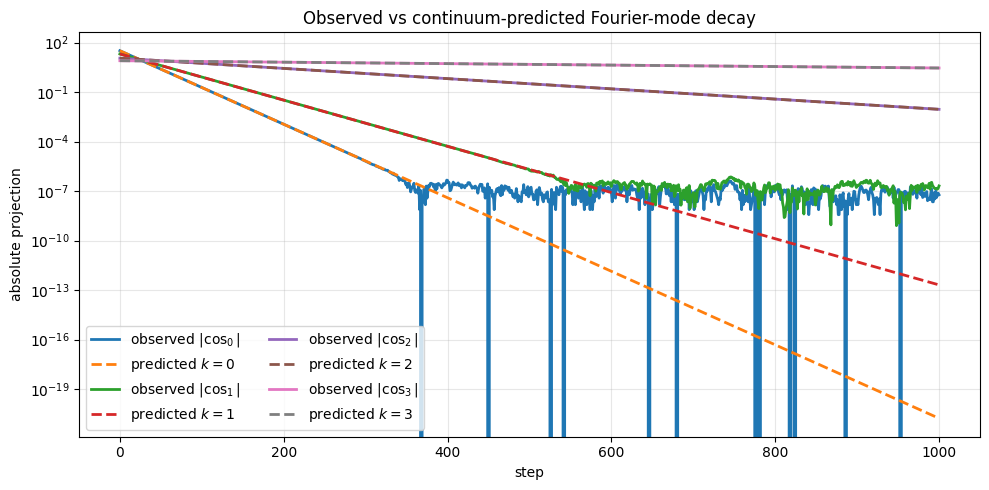

In [59]:
# Observed Fourier-mode decay vs continuum-predicted decay

if continuum_spectrum is None:
    print("No continuum_spectrum artifact found for this run.")
else:
    ks_compare = continuum_spectrum["ks_compare"]
    lambda_disc_pred = continuum_spectrum["lambda_disc_pred"]
    lam_map = {int(k): float(lam) for k, lam in zip(ks_compare, lambda_disc_pred)}

    plt.figure(figsize=(10, 5))

    for k in modes_to_plot:
        key = f"cos_{k}"
        if key not in mode_projections or k not in lam_map:
            print(f"Missing data for mode k={k}")
            continue

        obs = np.asarray(mode_projections[key])
        pred = np.abs(obs[0]) * (1.0 - eta * lam_map[k]) ** np.arange(len(obs))

        plt.plot(np.abs(obs), linewidth=2, label=rf"observed $|\cos_{k}|$")
        plt.plot(pred, "--", linewidth=2, label=rf"predicted $k={k}$")

    plt.yscale("log")
    plt.xlabel("step")
    plt.ylabel("absolute projection")
    plt.title("Observed vs continuum-predicted Fourier-mode decay")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

## Why the decay does not look equally fast across modes

### 1. In discrete time, the exact law is geometric

For an eigenmode $q_k$ with eigenvalue $\lambda_k$, the residual coefficient satisfies
$$
\alpha_k(t+1) = (1-\eta\lambda_k)\,\alpha_k(t),
$$
so
$$
\alpha_k(t) = (1-\eta\lambda_k)^t \,\alpha_k(0).
$$

This is **geometric decay** in the step index $t$.

When $\eta \lambda_k$ is small,
$$
(1-\eta\lambda_k)^t \approx e^{-\eta\lambda_k t},
$$
so it looks exponential. On a semilog plot, both appear as straight lines.

So the correct interpretation is:

- exact discrete-time behavior: geometric,
- small-step / gradient-flow approximation: exponential.

---

### 2. Different modes decay at very different rates

The plots are actually showing exactly this effect.

For the present setup, the first mode has a much larger eigenvalue than modes $3$ and $8$, so it decays much faster.

Very roughly, with $n=1024$ and the bias kernel,
$$
\lambda_1^{\mathrm{disc}} \approx 360,
\qquad
\lambda_3^{\mathrm{disc}} \approx 11.5,
\qquad
\lambda_8^{\mathrm{disc}} \approx 1.75.
$$

If the step size is chosen as
$$
\eta = \frac{0.05}{\lambda_{\max}},
$$
and $\lambda_{\max} \approx 567$, then
$$
\eta \approx 8.8 \times 10^{-5}.
$$

So the per-step decay factors are approximately
$$
1-\eta\lambda_1 \approx 0.968,
$$
$$
1-\eta\lambda_3 \approx 0.9990,
$$
$$
1-\eta\lambda_8 \approx 0.99985.
$$

Now look at what this implies over $400$ steps.

For mode $1$,
$$
(1-\eta\lambda_1)^{400} \approx e^{-12.8} \ll 1,
$$
so mode $1$ decays very strongly.

For mode $3$,
$$
(1-\eta\lambda_3)^{400} \approx e^{-0.4} \approx 0.67,
$$
so mode $3$ only decays moderately.

For mode $8$,
$$
(1-\eta\lambda_8)^{400} \approx e^{-0.06} \approx 0.94,
$$
so mode $8$ is almost flat on this time window.

This is exactly what the plot shows.

So the reason it does not look like “everything decays exponentially” is not that the theory failed. It is that the higher modes are still decaying exponentially / geometrically, but with very small decay exponents on the time interval being plotted.

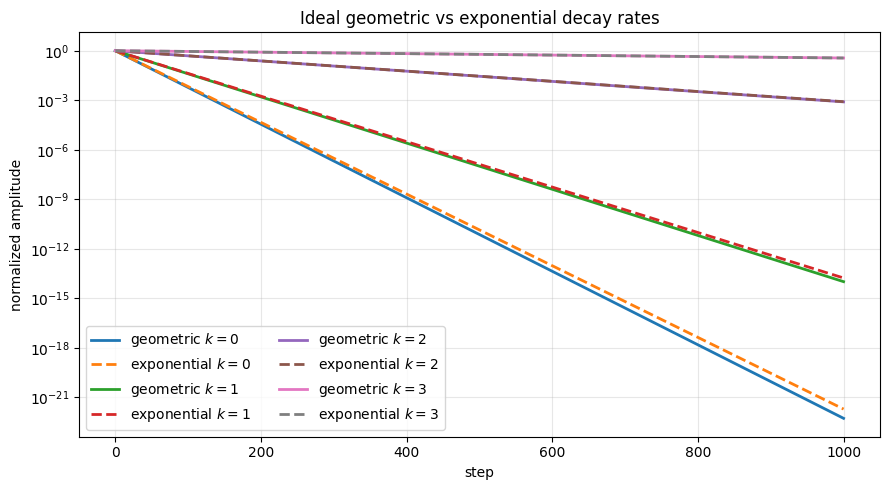

In [60]:
# Ideal normalized geometric / exponential decay curves for selected modes

modes_to_plot = [0, 1, 2, 3]
steps_arr = np.arange(len(loss))

# Build lambda map from the continuum prediction saved in the run
lam_map = {int(k): float(lam) for k, lam in zip(
    continuum_spectrum["ks_compare"],
    continuum_spectrum["lambda_disc_pred"],
)}

plt.figure(figsize=(9, 5))

for k in modes_to_plot:
    lam = lam_map[k]

    geom = np.abs(1.0 - eta * lam) ** steps_arr
    expo = np.exp(-eta * lam * steps_arr)

    plt.plot(geom, linewidth=2, label=rf"geometric $k={k}$")
    plt.plot(expo, "--", linewidth=2, label=rf"exponential $k={k}$")

plt.yscale("log")
plt.xlabel("step")
plt.ylabel("normalized amplitude")
plt.title("Ideal geometric vs exponential decay rates")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

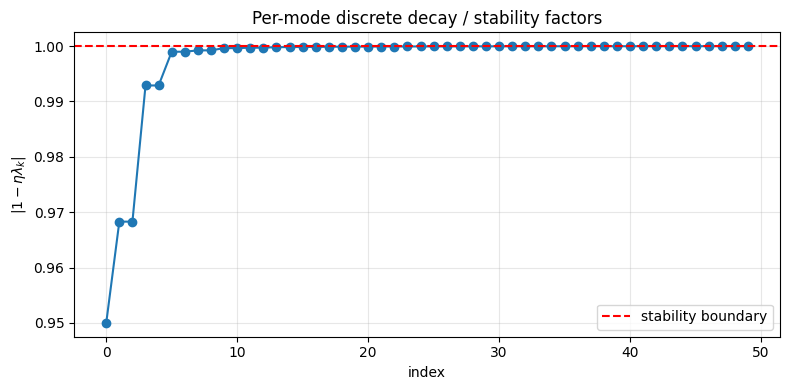

max |1 - eta * lambda_k| = 0.99999994
min |1 - eta * lambda_k| = 0.95


In [61]:
# check stability factor |1 - eta * lambda_k|

stab = np.abs(1.0 - eta * evals_emp)

plt.figure(figsize=(8, 4))
plt.plot(stab[:50], marker="o", linewidth=1.5)
plt.axhline(1.0, color="red", linestyle="--", label="stability boundary")
plt.xlabel("index")
plt.ylabel(r"$|1 - \eta \lambda_k|$")
plt.title("Per-mode discrete decay / stability factors")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("max |1 - eta * lambda_k| =", stab.max())
print("min |1 - eta * lambda_k| =", stab.min())

In [17]:
# Optional diagnostic: compare target Fourier content at t=0 residual
# For zero init, r_0 = -y, so these are basically the target coefficients up to sign.

diag_modes = [0, 1, 2, 3, 4, 8, 12]

rows = []
for k in diag_modes:
    ckey = f"cos_{k}"
    skey = f"sin_{k}"
    c0 = float(mode_projections[ckey][0]) if ckey in mode_projections else np.nan
    s0 = float(mode_projections[skey][0]) if skey in mode_projections else np.nan
    rows.append((k, c0, s0))

print("Initial residual Fourier projections:")
print("k   cos_k                sin_k")
for k, c0, s0 in rows:
    print(f"{k:<2d}  {c0: .6e}    {s0: .6e}")

Initial residual Fourier projections:
k   cos_k                sin_k
0   -1.845183e-07     nan
1   -4.970493e-07    -2.262742e+01
2    7.064521e-08     7.638494e-07
3   -3.390773e-07    -1.583919e+01
4   -1.165722e-08     4.895822e-07
8    2.214899e-07    -7.919598e+00
12   nan     nan


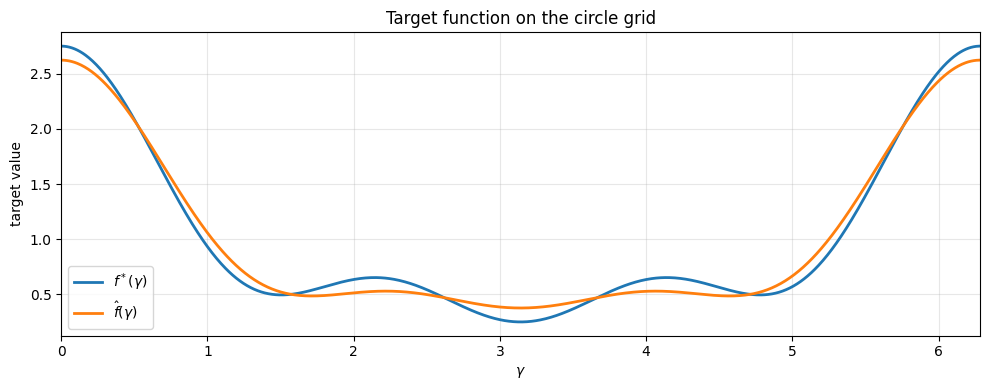

In [64]:
y_pred_final = kernel_dynamics["y_pred"][-1]
plt.figure(figsize=(10, 4))
plt.plot(gamma_train, y_train, linewidth=2, label=r"$f^*(\gamma)$")
plt.plot(gamma_train, y_pred_final, linewidth=2, label=r"$\hat{f}(\gamma)$")
plt.xlabel(r"$\gamma$")
plt.ylabel("target value")
plt.title("Target function on the circle grid")
plt.xlim(0, 2 * np.pi)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
